# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Johana Oktavia Ramadhani
- **Email:** 111202315024@mhs.dinus.ac.id
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan kontribusi pengguna Casual vs Registered di setiap musim pada periode 2011-2012? Di musim manakah pengguna Casual paling banyak berkontribusi terhadap total penyewaan?
- Pada jam berapa puncak penyewaan sepeda terjadi pada hari kerja dibandingkan hari libur selama tahun 2012, dan bagaimana strategi distribusi armada yang sebaiknya diterapkan?

## Import Semua Packages/Library yang Digunakan

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

### Gathering Data

In [25]:
dday = pd.read_csv("data/day.csv")
dday.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [26]:
dhour = pd.read_csv("data/hour.csv")
dhour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day terdiri dari 16 kolom yang memberikan ringkasan harian, sangat berguna untuk menganalisis tren musiman dan perbandingan antar tipe pengguna (Casual vs Registered).
- Dataset hour memiliki kolom tambahan hr (jam), yang krusial untuk menganalisis pola fluktuasi penyewaan sepeda pada jam-jam sibuk di hari kerja maupun hari libur.
- Data numerik seperti temp, atemp, hum, dan windspeed terlihat sudah dalam bentuk yang dinormalisasi (skala 0-1)

### Assessing Data

In [27]:
dday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [28]:
dday.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [29]:
dday.duplicated().sum()

np.int64(0)

In [30]:
dday.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [31]:
dhour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [32]:
dhour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [33]:
dhour.duplicated().sum()

np.int64(0)

In [34]:
dhour.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:**
- Tidak ada missing values atau data duplikat (kualitas data sangat baik).
- Kolom dteday perlu diubah dari object ke datetime untuk analisis waktu.
- Rentang penyewaan harian sangat luas (22–8.714 sepeda), menunjukkan pengaruh kuat faktor eksternal (cuaca/musim).
- Ada perbedaan besar antara rata-rata (189) dan nilai maksimum (977) per jam, mengindikasikan adanya jam sibuk (peak hours).
- Pada kolom casual, nilai rata-ratanya (~84) jauh di bawah nilai maksimumnya (3410 pada data harian). Hal ini mengindikasikan adanya outliers atau lonjakan pengguna kasual yang sangat tinggi pada hari-hari tertentu (seperti hari libur nasional atau festival)

### Cleaning Data

In [35]:
# Mengubah dteday menjadi datetime
dday['dteday'] = pd.to_datetime(dday['dteday'])
dhour['dteday'] = pd.to_datetime(dhour['dteday'])

In [36]:
# Mengubah angka musim menjadi label teks
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
dday['season'] = dday['season'].map(season_labels)
dhour['season'] = dhour['season'].map(season_labels)

In [37]:
# Mengubah angka weathersit menjadi label teks
weather_labels = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
dday['weathersit'] = dday['weathersit'].map(weather_labels)
dhour['weathersit'] = dhour['weathersit'].map(weather_labels)

In [38]:
dday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [39]:
dday.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Konversi dteday ke datetime memastikan akurasi analisis time-series dan mempermudah ekstraksi tren waktu (bulan/hari) tanpa kendala format.
- Labeling pada season dan weathersit meningkatkan keterbacaan data, mempercepat interpretasi grafik, dan meminimalisir kesalahan pembacaan kode angka.
- Dataset kini bersih dan konsisten. Penyimpanan ke main_data.csv mengoptimalkan alur kerja (workflow) agar dashboard Streamlit dapat memuat data lebih cepat tanpa proses ulang.

## Exploratory Data Analysis (EDA)

### Explore ...

In [40]:
#pola penyewaan per jam by hari kerja
dday.groupby(by="season").agg({
    "casual": ["mean", "sum"],
    "registered": ["mean", "sum"],
    "cnt": ["mean", "sum"]
})

casual           registered                  cnt         
               mean     sum         mean     sum         mean      sum
season                                                                
Fall    1202.611702  226091  4441.691489  835038  5644.303191  1061129
Spring   334.928177   60622  2269.204420  410726  2604.132597   471348
Summer  1106.097826  203522  3886.233696  715067  4992.331522   918589
Winter   729.112360  129782  3999.050562  711831  4728.162921   841613

**Insight:**
- Pengguna terdaftar (Registered) merupakan tulang punggung bisnis di semua musim, dengan kontribusi volume penyewaan tertinggi terjadi pada musim gugur (Fall).
- Musim gugur mencatat performa terbaik dengan rata-rata $5.644$ penyewaan per hari. Musim panas (Summer) menyusul sebagai periode tersibuk kedua, menunjukkan korelasi positif antara cuaca yang lebih hangat dengan aktivitas bersepeda.
- Kontribusi pengguna kasual sangat fluktuatif; meningkat hampir 4x lipat pada musim panas dan gugur dibandingkan musim semi. Hal ini mengindikasikan bahwa tipe pengguna ini lebih dipengaruhi oleh faktor rekreasi dan cuaca.
- Musim semi (Spring) menjadi periode dengan performa terendah, di mana total penyewaan anjlok hingga di bawah 50% dibandingkan musim puncak. Ini menandakan perlunya strategi promosi khusus pada awal tahun.

In [ ]:
def get_time_category(hour):
    if 6 <= hour <= 10:
        return 'Morning Peak'
    elif 11 <= hour <= 15:
        return 'Mid-day'
    elif 16 <= hour <= 20:
        return 'Evening Peak'
    else:
        return 'Off-peak/Night'

dhour['time_category'] = dhour['hr'].apply(get_time_category)
advanced_grouping = dhour.groupby(by=["workingday", "time_category"])["cnt"].mean().unstack()
print(advanced_grouping)

time_category  Evening Peak     Mid-day  Morning Peak  Off-peak/Night
workingday                                                           
0                272.862847  355.553247    119.241110       67.079844
1                381.774077  188.496180    249.400806       57.586246


**Insight:**
- Kategori Evening Peak (16:00–20:00) menjadi periode tersibuk dengan rata-rata 381 sewa, disusul Morning Peak (249 sewa). Ini menunjukkan dominasi pengguna rutin untuk mobilitas kerja.
- Puncak penggunaan bergeser ke Mid-day (11:00–15:00) dengan rata-rata 355 sewa, mengindikasikan sepeda lebih banyak digunakan untuk aktivitas santai siang hari.
- Kategori Off-peak/Night pada hari libur tetap lebih tinggi dibanding hari kerja, mencerminkan aktivitas sosial malam yang lebih panjang di akhir pekan.
- Terdapat kontras tajam; Morning Peak dua kali lipat lebih ramai di hari kerja, sementara Mid-day dua kali lipat lebih ramai di hari libur.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan kontribusi pengguna Casual vs Registered di setiap musim pada periode 2011-2012? Di musim manakah pengguna Casual paling banyak berkontribusi terhadap total penyewaan?

In [44]:
# Mengelompokkan berdasarkan musim dan menjumlahkan (SUM)
season_analysis_df = dday.groupby('season').agg({
    'casual': 'sum',
    'registered': 'sum',
    'cnt': 'sum'
}).reset_index()

# Menghitung persentase kontribusi
season_analysis_df['casual_pct'] = (season_analysis_df['casual'] / season_analysis_df['cnt']) * 100
season_analysis_df['registered_pct'] = (season_analysis_df['registered'] / season_analysis_df['cnt']) * 100

print(season_analysis_df[['season', 'casual_pct', 'registered_pct']])

   season  casual_pct  registered_pct
0    Fall   21.306646       78.693354
1  Spring   12.861410       87.138590
2  Summer   22.155937       77.844063
3  Winter   15.420627       84.579373


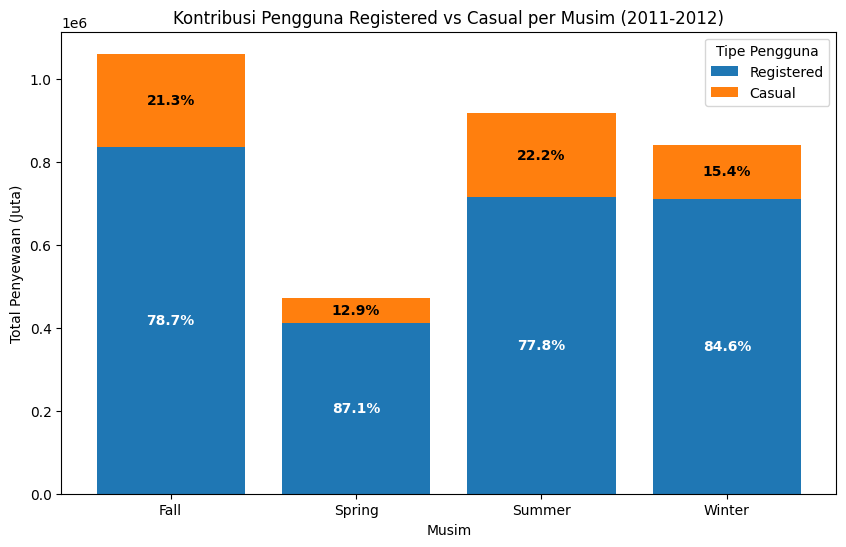

In [45]:
plt.figure(figsize=(10, 6))

# Membuat stacked bar
plt.bar(season_analysis_df['season'], season_analysis_df['registered'], label='Registered', color='#1f77b4')
plt.bar(season_analysis_df['season'], season_analysis_df['casual'], bottom=season_analysis_df['registered'], label='Casual', color='#ff7f0e')

# Menambahkan label persentase di dalam bar
for i, row in season_analysis_df.iterrows():
    plt.text(i, row['registered']/2, f"{row['registered_pct']:.1f}%", 
             ha='center', va='center', color='white', fontweight='bold')
    
    plt.text(i, row['registered'] + (row['casual']/2), f"{row['casual_pct']:.1f}%", 
             ha='center', va='center', color='black', fontweight='bold')

plt.title('Kontribusi Pengguna Registered vs Casual per Musim (2011-2012)')
plt.xlabel('Musim')
plt.ylabel('Total Penyewaan (Juta)')
plt.legend(title='Tipe Pengguna', loc='upper right')

plt.show()

**Insight: Komposisi Kontribusi Pengguna per Musim**
- Di setiap musim, pengguna Registered selalu menjadi kontributor utama dengan porsi di atas 77%. Hal ini menunjukkan bahwa bisnis Bike Sharing ini memiliki basis pelanggan setia atau komuter yang sangat kuat dan stabil di sepanjang tahun.
- Secara volume absolut, musim gugur (Fall) menyumbangkan total penyewaan tertinggi, menembus angka lebih dari 1 juta penyewaan. Ini menjadikannya musim paling menguntungkan bagi operasional bisnis.
- Menjawab pertanyaanmu, pengguna Casual paling banyak berkontribusi terhadap total penyewaan pada musim Fall secara volume (angka absolut tertinggi). Namun, jika dilihat dari sisi proporsi (persentase), musim Summer mencatatkan porsi Casual terbesar yaitu 22.2%.
- Kontribusi pengguna Casual berada pada titik terendah di musim Spring, baik secara volume maupun persentase (12.9%). Hal ini mengindikasikan bahwa pengguna non-langganan cenderung menghindari penggunaan sepeda saat transisi cuaca dingin, sementara pengguna Registered tetap menggunakannya untuk kebutuhan esensial/bekerja.

### Pertanyaan 2: Pada jam berapa puncak penyewaan sepeda terjadi pada hari kerja dibandingkan hari libur selama tahun 2012, dan bagaimana strategi distribusi armada yang sebaiknya diterapkan?

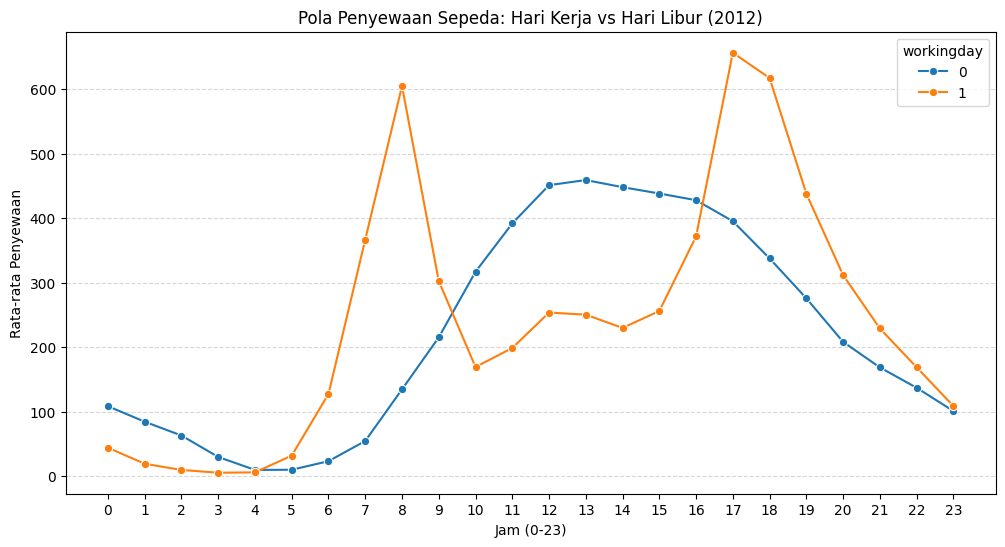

In [46]:
dhour_2012 = dhour[dhour['dteday'].dt.year == 2012]

hourly_pattern_2012 = dhour_2012.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=hourly_pattern_2012,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o',
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Pola Penyewaan Sepeda: Hari Kerja vs Hari Libur (2012)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

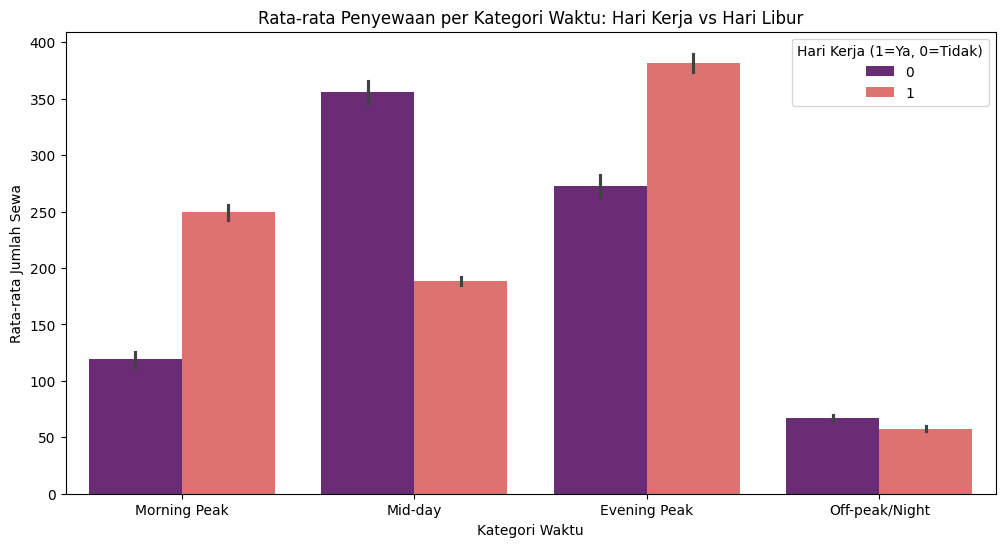

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=dhour, 
    x='time_category', 
    y='cnt', 
    hue='workingday', 
    order=['Morning Peak', 'Mid-day', 'Evening Peak', 'Off-peak/Night'],
    palette='magma'
)
plt.title('Rata-rata Penyewaan per Kategori Waktu: Hari Kerja vs Hari Libur')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.xlabel('Kategori Waktu')
plt.legend(title='Hari Kerja (1=Ya, 0=Tidak)')
plt.show()

**Insight: Analisis Pola Waktu & Strategi Distribusi**
- Line chart menunjukkan double peak (08:00 & 17:00) pada hari kerja dan bell curve (12:00-15:00) pada hari libur. Analisis grouping mempertegas bahwa Evening Peak adalah periode tersibuk secara makro dengan rata-rata 381 sewa di hari kerja.
- Strategi distribusi harus asimetris. Pada hari kerja, fokuskan stok di residensial (pagi) dan area bisnis (sore). Pada hari libur, geser konsentrasi armada ke area wisata sejak kategori Mid-day dimulai (jam 11:00).
- Volume hari kerja jauh lebih tinggi (>600 unit pada puncak jam). Penyeimbangan armada wajib dilakukan sebelum kategori Morning Peak (di bawah jam 07:00) dan perawatan rutin dilakukan pada kategori Off-peak/Night (00:00–04:00).
- Meskipun volume rendah, kategori Off-peak/Night di hari libur lebih tinggi dibanding hari kerja, menunjukkan adanya potensi pasar dari aktivitas hiburan malam.

## Analisis Lanjutan (Opsional)

In [43]:
dhour.to_csv("dashboard/main_data.csv", index=False)

## Conclusion

- Pertanyaan 1: Kontribusi Tipe Pengguna & Pengaruh Musim
Pengguna Registered mendominasi operasional dengan kontribusi stabil di atas 75% di semua musim sebagai basis pelanggan loyal. Namun, pertumbuhan bisnis sangat bergantung pada segmen Casual yang melonjak drastis saat cuaca hangat di musim Fall dan Summer, sehingga strategi pemasaran harus difokuskan pada paket rekreasi musiman untuk memaksimalkan konversi pengguna non-rutin.
- Pertanyaan 2: Pola Waktu & Optimalisasi Distribusi (Advanced Analysis)
Berdasarkan Manual Grouping, ditemukan pola komuter pada jam sibuk kerja (Morning & Evening Peak) dan pola rekreasi pada siang hari libur (Mid-day). Efisiensi operasional harus dicapai melalui rebalancing armada yang dinamis, dengan memusatkan unit di area residensial pada pagi hari kerja dan mengalihkannya ke pusat wisata atau ruang publik saat akhir pekan.